<a href="https://colab.research.google.com/github/desai179/-BME450-skincancer/blob/main/CNN2Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu

Class balance: 38 benign, 11 malignant
Epoch 1/50 | Loss: 1.0142 | Train Acc: 22.45% | Test Acc: 100.00%
Epoch 2/50 | Loss: 0.9254 | Train Acc: 77.55% | Test Acc: 100.00%
Epoch 3/50 | Loss: 0.9385 | Train Acc: 77.55% | Test Acc: 100.00%
Epoch 4/50 | Loss: 0.9585 | Train Acc: 77.55% | Test Acc: 100.00%
Epoch 5/50 | Loss: 1.6477 | Train Acc: 77.55% | Test Acc: 93.10%
Epoch 6/50 | Loss: 0.9506 | Train Acc: 75.51% | Test Acc: 6.90%
Epoch 7/50 | Loss: 1.0020 | Train Acc: 22.45% | Test Acc: 0.00%
Epoch 8/50 | Loss: 0.9834 | Train Acc: 24.49% | Test Acc: 10.34%
Epoch 9/50 | Loss: 0.9047 | Train Acc: 44.90% | Test Acc: 72.41%
Epoch 10/50 | Loss: 1.1420 | Train Acc: 79.59% | Test Acc: 89.66%
Epoch 11/50 | Loss: 0.8823 | Train Acc: 81.63% | Test Acc: 89.66%
Epoch 12/50 | Loss: 0.8911 | Train Acc: 81.63% | Test Acc: 86.21%
Epoch 13/50 | Loss: 0.8194 | Train Acc: 81.63% | Test Acc: 86.21%
Epoch 14/50 | Loss: 0.8492 | Train Acc: 81.63% | Test Acc: 86.21%
Epoch 15/50 | Loss: 0.828

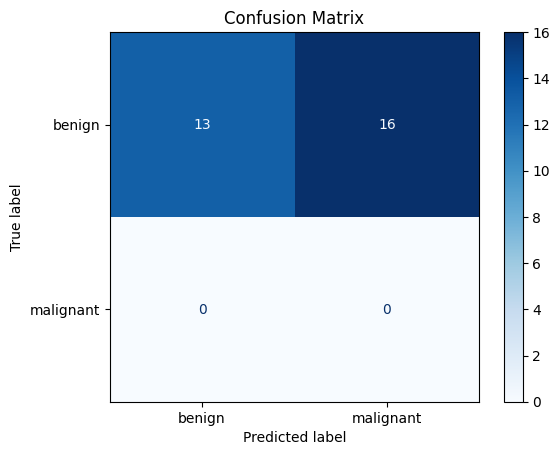

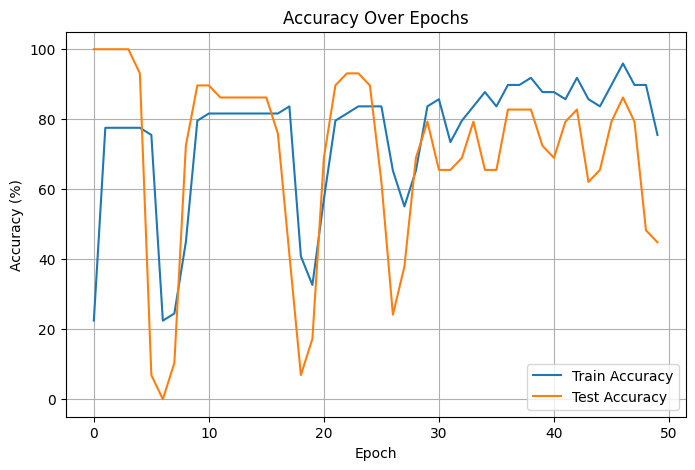

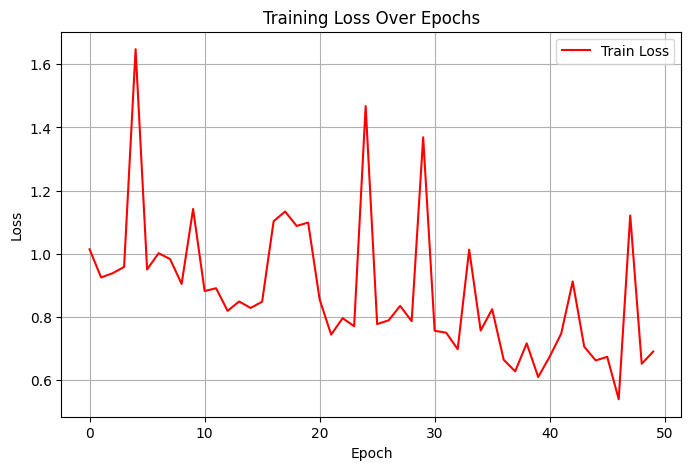


Sample Predictions:


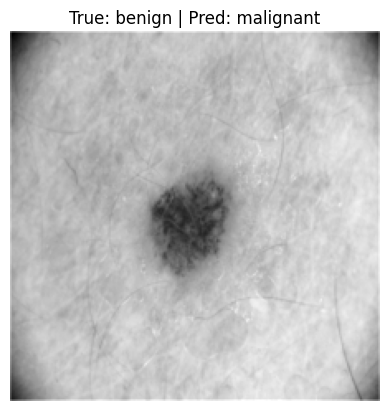

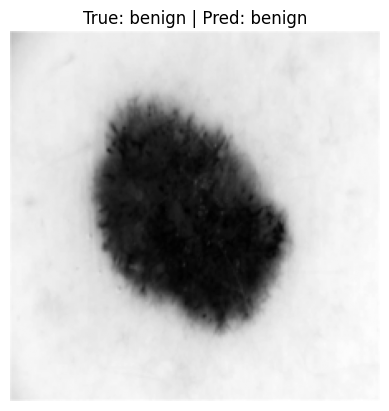

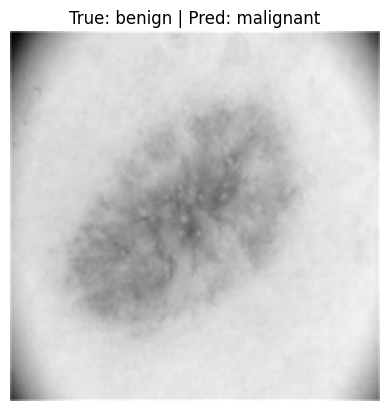

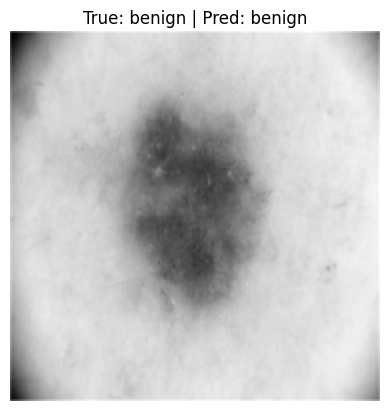

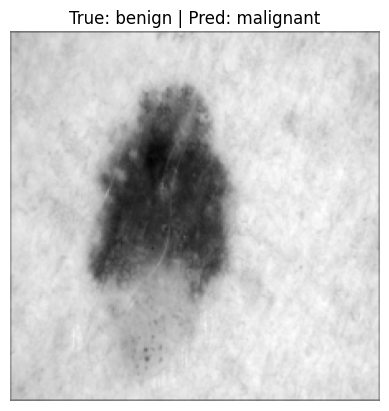

In [ ]:
# Unzip the dataset into the working directory
!unzip -o -q bme450project.zip -d bme450project

# Import necessary libraries for loading data, training models, and plotting results
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set device for GPU or CPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define transformations to resize images and convert them to grayscale
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# Set paths to the image directories and label CSV files
base_path = 'bme450project/bme450project'
train_images_path = os.path.join(base_path, 'LesionTraining')
test_images_path = os.path.join(base_path, 'LesionTesting')
train_labels_path = os.path.join(base_path, 'TrainingAnswers', 'TrainingAnswers.csv')
test_labels_path = os.path.join(base_path, 'TestAnswers', 'TestAnswers.csv')

# Define a custom dataset class for loading lesion images and labels
class LesionDataset(Dataset):
    def __init__(self, image_folder, labels_file, transform=None):
        self.image_folder = image_folder
        self.labels = pd.read_csv(labels_file)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        filename = self.labels.iloc[index, 0] + '.jpg'
        label_text = self.labels.iloc[index, 1]
        label = 1 if str(label_text).lower() == 'malignant' else 0
        image_path = os.path.join(self.image_folder, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Load training and testing datasets with the defined grayscale transformations
batch_size = 16
workers = 2
train_dataset = LesionDataset(train_images_path, train_labels_path, transform=train_transforms)
test_dataset = LesionDataset(test_images_path, test_labels_path, transform=test_transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers)

# Compute positive class weight to address class imbalance between benign and malignant samples
def calculate_class_weight(labels_csv):
    labels = pd.read_csv(labels_csv)
    malignant_count = sum(labels.iloc[:, 1].astype(str).str.lower() == 'malignant')
    benign_count = sum(labels.iloc[:, 1].astype(str).str.lower() == 'benign')
    print(f"\nClass balance: {benign_count} benign, {malignant_count} malignant")
    return torch.tensor([benign_count / malignant_count], device=device)

positive_class_weight = calculate_class_weight(train_labels_path)

# Define a simple CNN model with only two convolutional layers
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 1 input channel (grayscale), 16 output channels
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 input channels, 32 output channels
        self.fc1 = nn.Linear(32 * 56 * 56, 1)  # Flatten feature maps for binary classification

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56)
        x = self.fc1(x)
        return x

# Create the CNN model a
model = SimpleCNN().to(device)

# Define the loss function and optimizer
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_class_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Initialize lists to store loss and accuracy for plotting
training_accuracy = []
testing_accuracy = []
training_loss = []

# Define function to evaluate model performance on a dataset
def evaluate_model(model, data_loader, show_full_report=False):
    model.eval()
    correct_predictions, total_samples = 0, 0
    all_predictions, all_true_labels = [], []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).squeeze().int()
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_predictions.extend(preds.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())

    accuracy = 100 * correct_predictions / total_samples
    if show_full_report:
        print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
        print(classification_report(all_true_labels, all_predictions, target_names=["benign", "malignant"], zero_division=0))
        cm = confusion_matrix(all_true_labels, all_predictions, labels=[0, 1])
        display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "malignant"])
        display.plot(cmap='Blues')
        plt.title("Confusion Matrix")
        plt.show()
    return accuracy

# Define function to train the model for one epoch
def train_model_for_one_epoch(model, data_loader, optimizer, loss_function):
    model.train()
    running_loss = 0
    correct_predictions, total_samples = 0, 0
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).int()
        correct_predictions += (preds.squeeze() == labels.squeeze().int()).sum().item()
        total_samples += labels.size(0)
    training_accuracy_epoch = 100 * correct_predictions / total_samples
    return running_loss / len(data_loader), training_accuracy_epoch

# Train the model and collect loss and accuracy statistics over epochs
total_epochs = 50
for epoch in range(total_epochs):
    epoch_loss, epoch_train_accuracy = train_model_for_one_epoch(model, train_loader, optimizer, loss_function)
    epoch_test_accuracy = evaluate_model(model, test_loader, show_full_report=False)
    training_loss.append(epoch_loss)
    training_accuracy.append(epoch_train_accuracy)
    testing_accuracy.append(epoch_test_accuracy)
    print(f"Epoch {epoch+1}/{total_epochs} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_accuracy:.2f}% | Test Acc: {epoch_test_accuracy:.2f}%")

# Perform final evaluation on the test set and display a confusion matrix
evaluate_model(model, test_loader, show_full_report=True)

# Plot training and testing accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(training_accuracy, label='Train Accuracy')
plt.plot(testing_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(training_loss, label='Train Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Define function to visualize a few sample predictions after training
def visualize_model_predictions(model, data_loader, number_of_images=5):
    model.eval()
    images_shown = 0
    class_names = ['benign', 'malignant']
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).squeeze().int()
            for i in range(len(images)):
                if images_shown >= number_of_images:
                    return
                img_array = images[i].cpu().permute(1, 2, 0).numpy().squeeze()
                plt.imshow(img_array, cmap='gray')
                plt.title(f"True: {class_names[labels[i]]} | Pred: {class_names[preds[i]]}")
                plt.axis('off')
                plt.show()
                images_shown += 1

print("\nSample Predictions:")
visualize_model_predictions(model, test_loader)
